In [7]:
import pandas as pd

df = pd.read_excel(r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx", sheet_name="marketing_campaign")

# nominal
def OneHotEncoding(df, column):
    uniqueCols = df[column].unique()
    for col in uniqueCols:
        s = df[column] == col                #boolean outcome
        df[col] = s.astype(int)              # converting to Os and 1s i.e encoding and creates and stores in new columns
    return df[uniqueCols]

#ordinal
def LabelEncoding(df, column):
    myDict = {}
    ucols = df[column].unique()
    for i in range(len(ucols)):
        myDict[ucols[i]] = i
    return df[column].map(myDict)            # appends values for all rows (keys) from the dictionary to empty list by looping

res = OneHotEncoding(df, "Marital_Status")
print("One Hot Encoding")
print(res)

print("\nLabel Encoding")
print(LabelEncoding(df, "Education"))

One Hot Encoding
      Single  Together  Married  Divorced  Widow  Alone  Absurd  YOLO
0          1         0        0         0      0      0       0     0
1          1         0        0         0      0      0       0     0
2          0         1        0         0      0      0       0     0
3          0         1        0         0      0      0       0     0
4          0         0        1         0      0      0       0     0
...      ...       ...      ...       ...    ...    ...     ...   ...
2235       0         0        1         0      0      0       0     0
2236       0         1        0         0      0      0       0     0
2237       0         0        0         1      0      0       0     0
2238       0         1        0         0      0      0       0     0
2239       0         0        1         0      0      0       0     0

[2240 rows x 8 columns]

Label Encoding
0       0
1       0
2       0
3       0
4       1
       ..
2235    0
2236    1
2237    0
2238    2
22

In [24]:
def MinkowskiDist(p, X, Y):
    sum = 0
    for i in range(len(X)):
        sum += abs(X[i] - Y[i])**p
    return (sum)**(1/p)

X = [2,-1,3]
Y = [1,4,-2]
# n = int(input("Enter dimension:"))
# for _ in range(n):
#     print("Enter for X")
#     X.append(int(input()))
# for _ in range(n):
#     print("Enter for Y")
#     Y.append(int(input()))
print("Manhattan distance")
print(MinkowskiDist(1, X, Y))
print("Euclidean distance")
print(MinkowskiDist(2, X, Y))

Manhattan distance
11.0
Euclidean distance
7.14142842854285


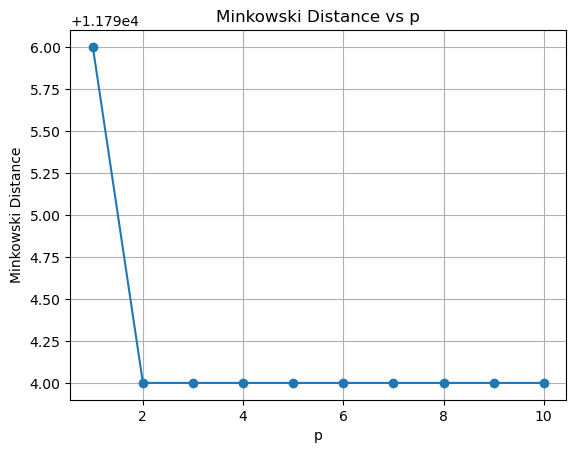

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def MinkowskiDist(p, X, Y):
    sum = 0
    for i in range(len(X)):
        sum += abs(X[i] - Y[i])**p
    return (sum)**(1/p)

df = pd.read_excel(r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx", sheet_name="marketing_campaign")
f = df.loc[[0,1]]
X = df.loc[0, ["Income", "Kidhome", "Teenhome"]]
Y = df.loc[1, ["Income", "Kidhome", "Teenhome"]]
distances = []
for i in range(1, 11):
    d = MinkowskiDist(i, X, Y)
    distances.append(d)

plt.plot(range(1, 11), distances, marker='o')
plt.xlabel("p")
plt.ylabel("Minkowski Distance")
plt.title("Minkowski Distance vs p")
plt.grid(True)
plt.show()